# Adult Income Prediction using Random Forest

This project aims to predict whether an individual earns more than $50K per year using machine learning.

In [9]:
import pandas as pd

df = pd.read_csv("data/group7-adult.csv")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,24,Private,291355,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,60,United-States,<=50K
1,34,Private,154874,HS-grad,9,Never-married,Machine-op-inspct,Not-in-family,White,Male,4416,0,30,United-States,<=50K
2,44,Private,223308,Masters,14,Separated,Sales,Unmarried,White,Female,0,0,48,United-States,<=50K
3,30,Private,323054,10th,6,Divorced,Other-service,Not-in-family,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
4,23,Private,180339,Assoc-acdm,12,Never-married,Sales,Own-child,White,Female,0,0,65,United-States,<=50K


## Data Cleaning

In this step, we handle missing values and remove unnecessary columns to improve data quality.

In [2]:
# remove missing values
df = df.replace(" ?", pd.NA)
df = df.dropna()

# drop unnecessary column
df = df.drop("fnlwgt", axis=1)

df.shape

(27205, 14)

# Target Variable Encoding

We convert income into numerical values:
- 0 = <=50K
- 1 = >50K

In [3]:
df["income"] = df["income"].apply(lambda x: 1 if ">50K" in x else 0)

df["income"].value_counts()

income
0    20468
1     6737
Name: count, dtype: int64

# Data Encoding

We convert categorical variables into numerical format using one-hot encoding.

In [4]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,24,10,0,0,60,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,34,9,4416,0,30,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,44,14,0,0,48,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,30,6,0,0,40,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,23,12,0,0,65,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


# Train-Test Split

We split the dataset into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training (Random Forest)

We use Random Forest because it is accurate and handles complex data well.

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier

start = time.time()

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

end = time.time()

print("Training time:", end - start, "seconds")

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Evaluation

We evaluate the model using accuracy and classification metrics.

In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8380812350670832
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4074
           1       0.70      0.62      0.66      1367

    accuracy                           0.84      5441
   macro avg       0.79      0.76      0.78      5441
weighted avg       0.83      0.84      0.83      5441



## Feature Importance

This shows which features are most influential in predicting income.

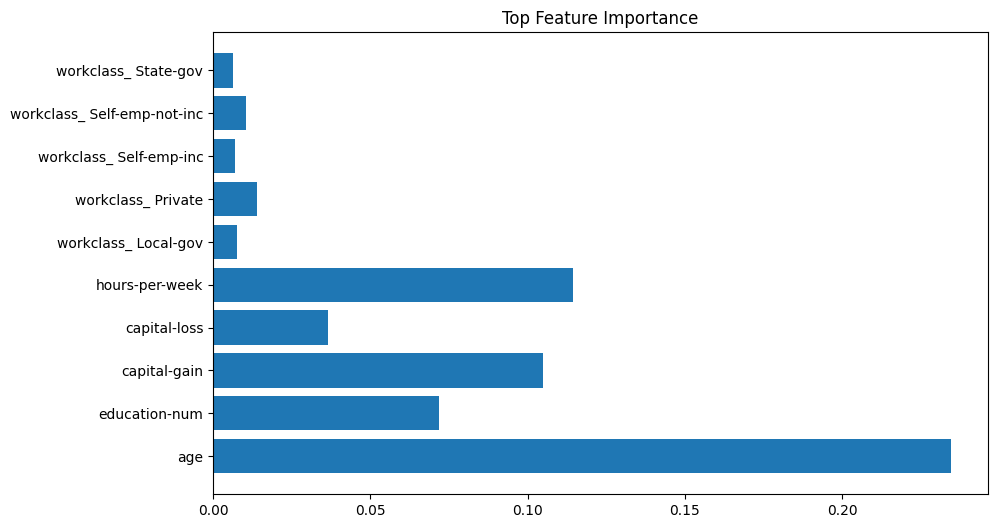

In [8]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features[:10], importances[:10])
plt.title("Top Feature Importance")
plt.show()